In [1]:
# autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# checkpoint_path = "/home/vittorio.zampinetti/cellmates_res/real_data/MM_03_cm_out"
# checkpoint_path = "/home/vittorio.zampinetti/data/cnasim_simulated_datasets/CNAsim/A2_1/1/cm_out"
checkpoint_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results/A2_1/1/cm_out"


In [3]:
import pickle
import os
from cellmates.utils.testing import plot_diagnostics

In [4]:
diagnostics = []
if os.path.exists(diag_path:=os.path.join(checkpoint_path, "em_diagnostics.pkl")):
    with open(diag_path, 'rb') as f:
        diagnostics_dict = pickle.load(f)
    for pair, d in diagnostics_dict.items():
        diagnostics.append({
            'pair': pair,
            'loglikelihoods': d['loglikelihoods'],
            'psis': d['psis'],
            'thetas': d['thetas'],
        })
    del diagnostics_dict
else:
    for filename in os.listdir(checkpoint_path):
        if filename.startswith("_checkpoint") and filename.endswith(".pkl"):
            with open(os.path.join(checkpoint_path, filename), "rb") as f:
                checkpoint = pickle.load(f)
                diagnostics.append(checkpoint)
                # print(checkpoint.keys())


In [5]:
# sanity checks on psi
for i, diags in enumerate(diagnostics):
    if i > 20:
        break
    print(diags['psis'])

[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 

CN MAD 0.0042375824939215


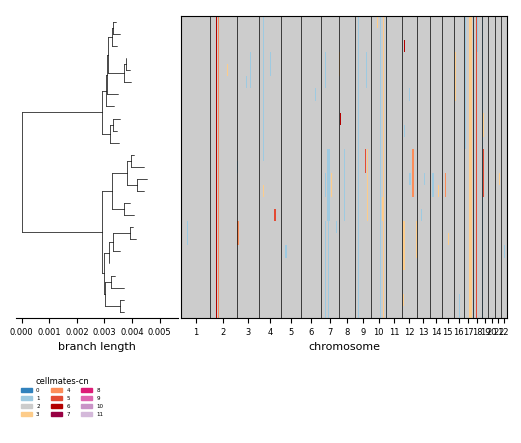

In [8]:
# if predicted_copy_numbers.npz available, plot with tree
if os.path.exists(os.path.join(checkpoint_path, "predicted_copy_numbers.npz")):
    import numpy as np
    import anndata
    import io
    from Bio import Phylo
    from cellmates.utils.tree_utils import newick_to_nx, nxtree_to_newick
    import matplotlib.pyplot as plt
    import scgenome.plotting as pl
    # get from parent of cm_out
    adata = anndata.read_h5ad(os.path.join(checkpoint_path, "..", "anndata.h5ad"))
    predicted_copy_numbers = np.load(os.path.join(checkpoint_path, "predicted_copy_numbers.npz"))
    cn_matrix = predicted_copy_numbers['data']
    # fill cells_idx
    mapp = {l: i for i, l in enumerate(predicted_copy_numbers['labels'])}
    cells_idx = [mapp[cell_name] for cell_name in adata.obs_names]
    adata.layers['cellmates-cn'] = cn_matrix[cells_idx]
    # tree
    tree_nwk = open(os.path.join(checkpoint_path, "tree.nwk")).read().strip()
    nx_tree = newick_to_nx(tree_nwk)
    bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight='weight')), "newick")
    # bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree)), "newick")
    g = pl.plot_cell_cn_matrix_fig(adata, layer_name='cellmates-cn', tree=bio_tree)
    print(f"CN MAD {np.mean(np.abs(adata.layers['cellmates-cn'] - adata.layers['state']))}")

[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([0.00028975, 0.00028975, 0.00028975]), array([0.00294428, 0.0009079 , 0.00117679]), array([0.00302539, 0.00091226, 0.00119271]), array([0.00302797, 0.00091325, 0.00119448]), array([0.00302763, 0.00091321, 0.00119435]), array([0.00302773, 0.0009132 , 0.00119429])]


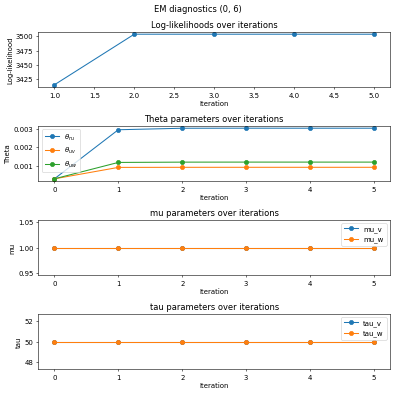

[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([0.00028975, 0.00028975, 0.00028975]), array([0.00283011, 0.00096916, 0.00048709]), array([0.0029105 , 0.00100071, 0.00048093]), array([0.00291087, 0.00100257, 0.00048005]), array([0.00291085, 0.00100239, 0.00047996]), array([0.00291078, 0.00100248, 0.00047996])]


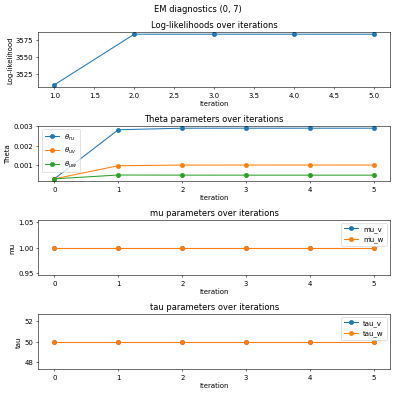

[array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.]), array([ 1., 50.,  1., 50.])]
[array([0.00028975, 0.00028975, 0.00028975]), array([0.00318336, 0.00071685, 0.00081179]), array([0.00330949, 0.00071527, 0.00081458]), array([0.00331477, 0.00071742, 0.00081655]), array([0.00331451, 0.00071753, 0.00081638]), array([0.00331437, 0.00071759, 0.00081632])]


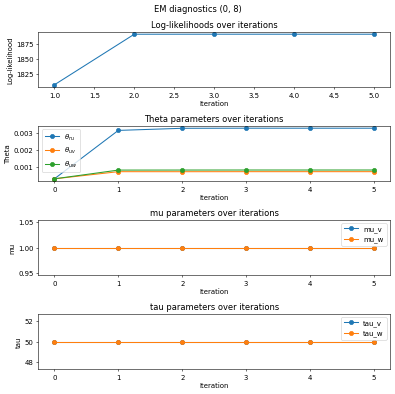

In [10]:
for i, diags in enumerate(diagnostics):
    if i > 2:
        break
    pair = diags['pair']
    print(diags['psis'])
    print(diags['thetas'])
    g = plot_diagnostics(diags, prefix=str(pair), psi_obs_model='normal', figsize=(8,8), dpi=50)
    # g = plot_diagnostics(diags, prefix=str(pair), psi_obs_model=None, figsize=(8,8), dpi=50)


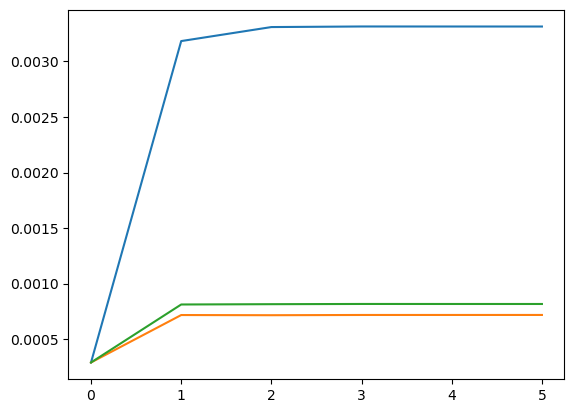

In [11]:
from matplotlib import pyplot as plt
pair_idx = 2
diagnostics[pair_idx]['thetas']
g = plt.plot(diagnostics[pair_idx]['thetas'])